# Introduction

Inventory management is one of the most critical functions in vehicle service centers. Service centers must maintain sufficient spare parts inventory to meet customer service demand for spare parts, minimizing storage and operational costs. However, predicting the demand for spare parts is challenging because it depends on multiple factors such as vehicle type, service frequency, mileage, and maintenance patterns. Poor inventory planning can result in either excess stock, which increases holding costs, or insufficient stock, which leads to service delays and customer dissatisfaction.

With the growth of data-driven technologies, Data Science and Machine Learning have become powerful tools for solving inventory management problems. By analyzing historical service records, organizations can predict future spare parts demand and optimize inventory levels accordingly. Predictive analytics enables service centres to understand usage patterns, identify high-demand spare parts, and forecast future consumption trends.

This project focuses on developing a Spare Parts Inventory Forecasting System using historical service center data stored in a MYSQL database. The project uses Python-based data science techniques such as data preprocessing, EDA, machine learning models, and time series forecasting to predict spare parts demands. The ultimate goal is to help service centres achieve Just-In-Time (JIT) inventory management, which ensures that spare parts are available when needed without maintaining excessive stock.

# Problem Statement

Managing spare parts inventory in vehicle service centres in complex challenge due to uncertain demand patterns. Service centres often keep large quantities of spare parts to avoid shortages, which increases inventory carrying costs and ties up capital. Despite maintaining high inventory levels, many service centers still experience spare parts shortages during peak service periods.

The absence of an accurate demand forecasting system results in inefficient inventory planning and operational inefficiencies. Without predictive insights, service centers rely on manual estimation or historical averages, which may not reflect real-time demand fluctuation. This problem affects service delivery performance and customer satisfaction.

Therefore, there is a need for a data-driven predictive system that can analyze historical service data and forecast spare parts demand accurately. Such a system can help service centers maintain optimal inventory levels, reduce operational costs, and improve service efficiency.


# Project Objectives

The main objective of this project is to develop a predictive model for spare parts inventory forecasting using historical service data stored in a MYSQL database.

The specific objectives of this project include:

- Extracting service center data from a MYSQL database.
- Performing data preprocessing and cleaning to handle missing values and data inconsistencies.
- Conducting EDA to identify patterns in spare parts usage.
- Developing machine learning models to predict spare parts demand.
- Implementing time series forecasting techniques to analyze future demand trends.
- Supporting service centres in implementing Just-In-Time (JIT) inventory management.
- Reducing spare parts inventory cost while ensuring availability.

# Dataset Description

The dataset used in this project is obtained from a MYSQL database containing service center operational records. The data represents historical service transactions and spare parts usage information collected from service centers.

The dataset contains 28,484 records and 7 attributes related to vehicle servicing operations. These attributes provide valuable insights into service activities, spare parts consumption patterns, and vehicle maintenance behavior.

The key features in the dataset include:

- Invoice Date - The date when the service invoice was generated.
- Job Card Date - The date when the service request was created.
- Business Partner Name - The name of the customer or service partner.
- Vehicle No - The unique vehicle identification number.
- Vehicle Model - The model of the serviced vehicle.
- Current KM Reading - The mileage of the vehicle during service.
- Invoice Line Text - Description of spare parts used during servicing.

The features allow the analysis of spare parts consumption patterns and help build predictive models for inventory forecasting.

### Future Description

#### 1. invoice_date
- Data Type: Object (Date/Time)
- Description: This column represents the date when the service invoice was generated for a vehicle after the completion of maintenance or repair work. It helps track when spare parts were officially billed in the service transaction.

#### 2. job_card_date
- Data Type: Object (Date/Time)
- Description: This column records the date when the service request or job card was created for a vehicle at the service center. it indicates when the servicing preocess started.

#### 3. business_partner_name
- Data Type: Object (Categorical)
- Description: This column contains the name of the customer or organization that owns the vehicle being serviced. it represents the business partner or client associated with each service transaction.

#### 4. vehicle_no
- Data Type: Object (Categorical/Identifer)
- Description: this column stored the unquie vehicle registration number for each vehicle serviced at the service centre. It acts as ab identifier for tracking vehicle service history.

#### 5. vehicle_model
- Data Type: Object (Categorical)
- Description: This column represents the type or model of the vehicle being services. Different vehicle models may require different spare parts and maintenance procedures.

#### 6. current_km_reading
- Data Type: Integer (Numerical)
- Description: This column records the odometer reading of the vehicle at the time of servicing. It indicates the total distance the vehicle has traveled and helps determine maintenance reqirements.

#### 7. invoice_line_text
- Data Type: Object (Categorical/Text)
- Description: This column contains the description of spare parts or service items included in the invoice. It provides about the specific spare parts used during vehicle servicing.

# Importance of Inventory Forecasting

Inventory forecasting plays a vital role in optimizing supply chain operations and service center management. Accurate demand forecasting helps organizations maintain the right balance between spare parts availability and inventory cost.

Some key benefits of inventory forecasting include:

- Reducing inventory holding and storage costs.
- Preventing spare parts shortages.
- Improving service efficiency and operational productivity.
- Supporting Just-In-Time inventory strategies.
- Enhancing customer satisfaction by reducing service delays.

By using predictive analytics and machine learning models, organizations can forecast spare parts demand more accurately and make better inventory management decisions.

# Scope of the project

- Extracting data from a MYSQL database
- Data preprocessing and feature engineering
- Exploratory Data Analysis and visualization
- Machine learning model development
- Time series forecasting for demand prediction
- Model evaluation and performance analysis

The system will help service centers improve spare parts inventory planning and achieve Just-In-Time (JIT) inventory standards, which ultimately reduces costs and improves operational efficiency.

# Install Required Libraries

In this initial step, all the necessary Python libraries required for the project are installed. These libraries provide the tools needed for database connectivity, data manipulation, visualization, machine learning modeling, and time series forecasting. The pymysql and sqlalchemy libraries are used to connect Python to the MySQL database. The pandas and numpy libraries are used to handle and process data efficiently. Visualization libraries such as matplotlib and seaborn help in analyzing patterns through graphs. The scikit-learn library is used for building machine learning models, while statsmodels provides statistical models such as ARIMA for forecasting future demand.

In [1]:
!pip install pymysql
!pip install sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.4 MB/s eta 0:00:00


##### Insight

Installing these libraries ensures that the environment supports all operations required for data extraction, preprocessing, model building, and demand forecasting.

# Import Required Libraries

After installing the required libraries, they are imported into the Python environment so their functions can be used in the project. The pandas library helps in managing structured data using DataFrames, while numpy supports numerical calculations. The sqlalchemy package is used to establish the connection between Python and the MYSQL database. Visualization libraries such as matplotlib and seaborn help in generating graphs to analyze trends and patterns. The LabelEncoder from scikit-learn converts categorical variables into numerical values so machine learning models can process them. The Random Forest algorithm is used for predictive modeling, and ARIMA is used for time series forecasting.

In [2]:
import pandas as pd
import numpy as np
import pymysql
from sqlalchemy import create_engine

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

# Connect to MYSQL Database

In this step, the program connects to the MYSQL database that contains the service centre data. The connection parameters, such as host address, database name, username, and password, are provided. Using the create_engine function from SQLAlchemy, a connection is established between Python and the database server.

In [3]:
from google.colab import userdata
from sqlalchemy import create_engine

# Securely fetch credentials from Colab's environment vault
host = userdata.get('DB_HOST')
database = userdata.get('DB_NAME')
user = userdata.get('DB_USER')
password = userdata.get('DB_PASSWORD')

# Build the connection string using the protected configuration variables
engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}/{database}")



##### Insight

Directly connecting to the database enables real-time data extraction and eliminates the need for manual dataset downloads, making the workflow more efficient and scalable.

# Dataset Export as CSV File

After extracting the dataset from the MYSQL database, it is exported as a CSV file for easier storage and analysis. CSV files are commonly used in Python data science workflows because they are lightweight and compatible with tools like Microsoft Excel and Jupyter Notebook. Saving the dataset locally avoids repeated database connections and makes the analysis process faster.

In [4]:
df=pd.read_csv("/content/service_data.csv")

In [5]:
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


##### Insight

Exporting the dataset to CSV enables faster experimentation, easier sharing of data, and efficient preprocessing for machine learning and forecasting models.

# Basic Dataset Information

Understanding the dataset structure is an important step before performing analysis. This shape function shows the number of rows and columns present in the dataset. The info() function displays the column names, data types, and number of non-null values. The describe() function provides statistical summaries such as mean, standard deviation, minimum, and maximum values for numerical features.

In [6]:
df.shape

(28482, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  int64 
 6   invoice_line_text      28448 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [8]:
df.describe()

,current_km_reading
count,28482.000000
mean,19348.003827
std,25246.722306
min,0.000000
25%,3988.000000
50%,12420.500000
75%,27905.000000
max,610112.000000


##### Insight

These functions help identify data quality issues, understand feature distributions, and determine whether additional preprocessing is required before building predictive models.

# Check Missing Values

Real-world datasets often contain missing or incomplete information. The isnull().sum() function calculates the number of missing values present in each column. Identifying missing values is important because machine learning algorithms cannot process incomplete data.

In [9]:
df.isnull().sum()

,0
invoice_date,0
job_card_date,0
business_partner_name,0
vehicle_no,0
vehicle_model,0
current_km_reading,0
invoice_line_text,34


##### Insight

Detecting missing values early helps in deciding whether to remove incomplete rows or apply imputation tecniques to fill missing values.

# Data Cleaning

Data cleaning ensures that the dataset is accurate and consistent before analysis. In this step, rows containing missing values are removed using the dropna() function. Additionally, the Invoice Date and Job Card Date columns are converted into a datetime format. Converting these columns extraction of time-realted features such as year, month, and day, which are important for time series analysis.

In [10]:
df=df.dropna()

In [11]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d-%m-%y')
df['job_card_date'] = pd.to_datetime(df['job_card_date'], format='%d-%m-%y')

##### Insight

Clean and properly formatted data improves model performance and prevents errors during future engineering and forecasting.

# Checking for Duplicate Records

Before performing data analysis, it is important to check whether the dataset contains duplicate rows. Duplicate records may occur due to repeated service entries, data import errors, or system synchronization issues. Identifying these duplicates ensures that each transaction is counted only once, which helps maintain the accuracy of spare parts demand analysis.

In [12]:
duplicate_count=df.duplicated().sum()
print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 367


##### Insight

This code checks the dataset for completely identical rows. If duplicates exist, they may artificially increase spare parts usage values and affect forecasting accuracy. Detecting duplicates ensures that the dataset reflects the actual service center transactions and real inventory demand patterns.

# Removing Duplicate Records (Before and After)

Duplicate records can affect the accuracy of the analysis because the same service transaction may appear multiple times in the dataset. Before removing duplicates, it is important to check how many duplicate rows exist. After identifying them, duplicates are removed to ensure that each record represents a unique service entry.

In [13]:
print("Shape before removing duplicates:", df.shape)

df=df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (28448, 7)
Shape after removing duplicates: (28081, 7)


##### Insight

Comparing the dataset shape before and after removing duplicates helps verify how many redundant rows were eliminated. This process ensures that the dataset contains unique records, which improves the accuracy of spare parts demand analysis and inventory forecasting models.

# Feature Engineering

Feature engineering involves creating new features from existing variables to improve predictive model performance. In this step, the year, month, and day are extracted from the invoice_date. The new features help capture temporal patterns in spare parts demand.

In [14]:
df['Year']=df['invoice_date'].dt.year
df['Month']=df['invoice_date'].dt.month
df['Day']=df['invoice_date'].dt.day

##### spare parts demand count

In [15]:
spare_demand=df.groupby(['Year', 'Month', 'invoice_line_text']).size().reset_index(name='Demand')
spare_demand.head()

,Year,Month,invoice_line_text,Demand
0,2017,5,3M OIL,2
1,2017,5,CHAIN LUBRICATION,2
2,2017,5,ENGINE OIL,5
3,2017,5,GENERAL SERVICE,1
4,2017,5,OIL FILTER,1


##### Insight

Grouping by year, month, and spare part description helps identify which spare parts are frequently used and during which periods.

# Exploratory Data Analysis (EDA)

EDA helps understand hidden patterns and trends in the dataset. Visualization techniques provide insights into spare parts demand distribution, vehicle servicing patterns, and frequently used spare parts.


### Spare Parts Demands Distribution

This histogram shows how spare demand is distributed across the dataset.

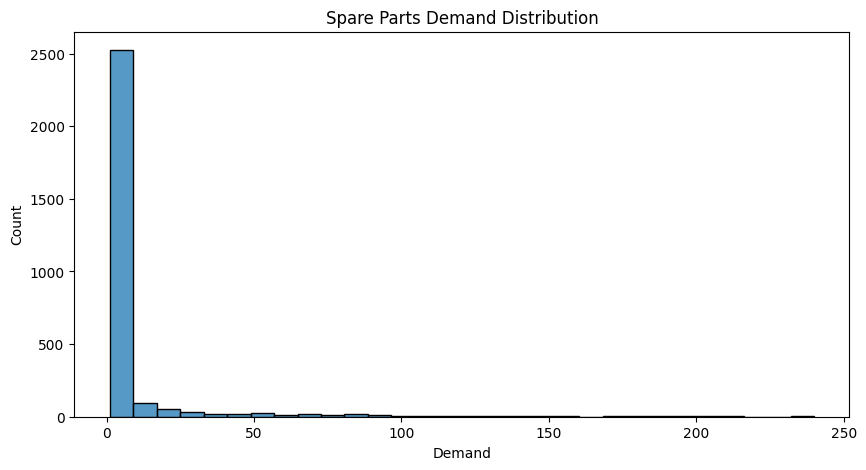

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(spare_demand['Demand'], bins=30)
plt.title("Spare Parts Demand Distribution")
plt.show()

##### Insight

If the distribution is skewed, it indicates that a few spare parts are used much more frequently than others.

### Top Frequently Used Spare Parts

This bar chart identifies the top 10 spare parts used during vehicle servicing.

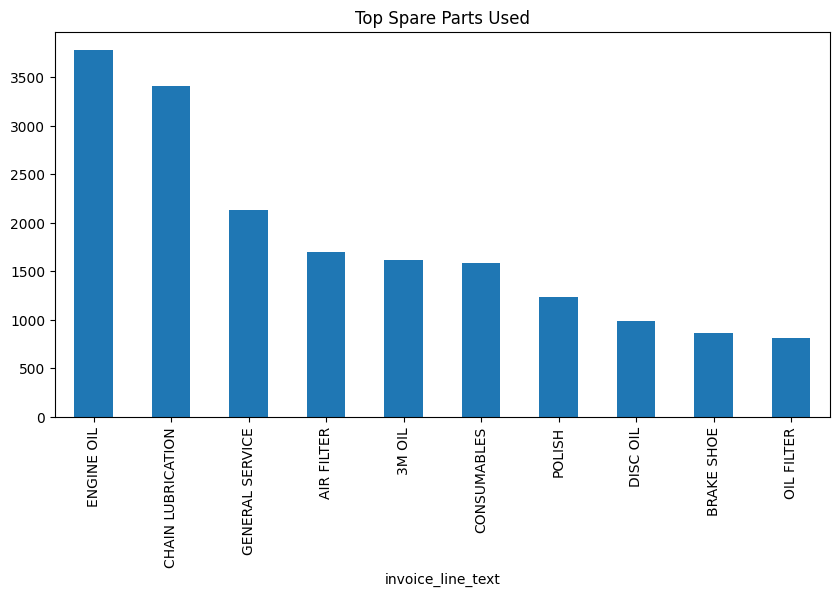

In [17]:
top_parts=df['invoice_line_text'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_parts.plot(kind='bar')
plt.title("Top Spare Parts Used")
plt.show()

##### Insight

Service centers should maintain higher stock levels for these high-demand spare parts to avoid service delays.

### Vehicle Model Distribution

This graph displays the most frequently serviced vehicle models.

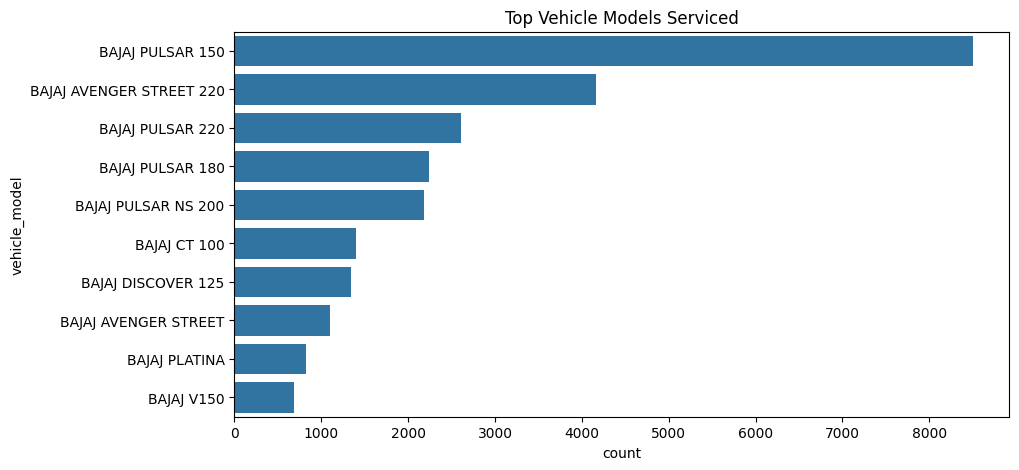

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(y='vehicle_model', data=df,
              order=df['vehicle_model'].value_counts().index[:10])
plt.title("Top Vehicle Models Serviced")
plt.show()

##### Insight

Certain vehicle models may require specific spare parts more frequently, which helps in targeted inventory planning.

# Vehicle Model Distribution

Vehicle models represent the different types of vehicles serviced at the service center. Analyzing the distribution of vehicle models helps identify which vehicles frequently visit the service center. Understanding vehicle model distribution is important because different vehicle models require different spare parts and maintenance schedules. By visualizing this information using a pie chart, we can easily identify the vehicle models that dominate service operations.

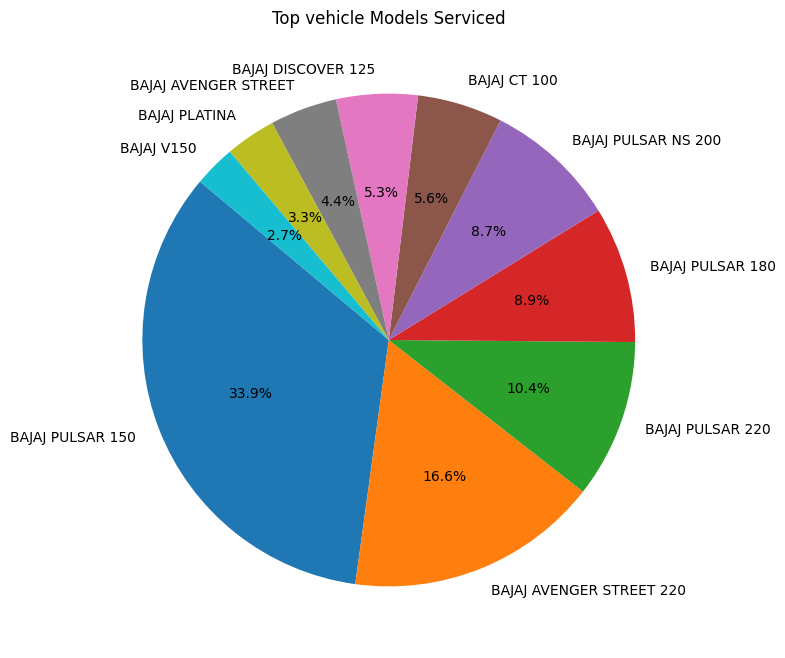

In [19]:
vehicle_model_counts=df['vehicle_model'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(vehicle_model_counts,
        labels=vehicle_model_counts.index,
        autopct='%1.1f%%',
        startangle=140)
plt.title("Top vehicle Models Serviced")
plt.show()

##### Insight

A few vehicle models dominate the service center visits. Spare parts demand is strongly related to vehicle model types.

# Business Partner Distribution

The business partner name column represents customers or organizations that bring vehicles for servicing. Analyzing the distribution of business partners helps identify key customers who frequently use the service center. This information is useful for understanding customer behavior and service demand patterns.

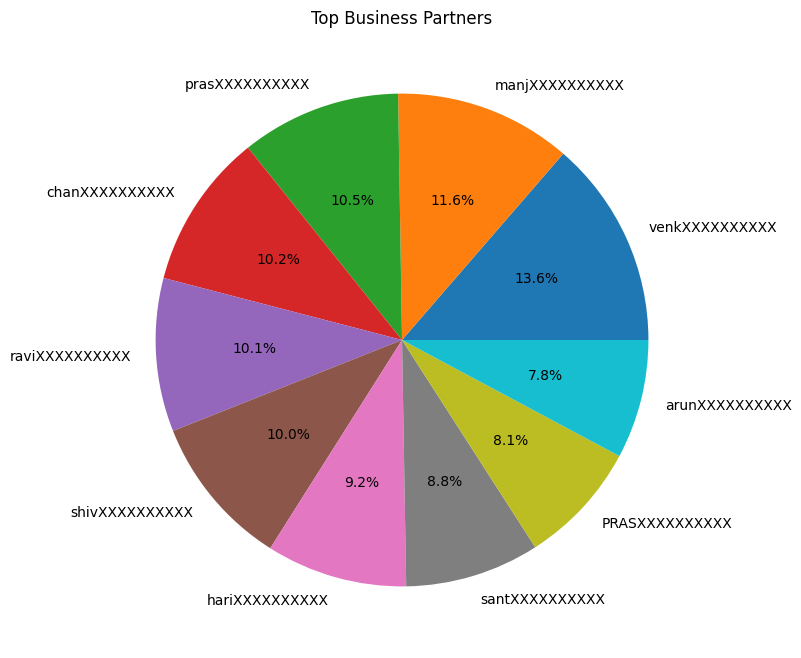

In [20]:
partner_counts=df['business_partner_name'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(partner_counts,
        labels=partner_counts.index,
        autopct='%1.1f%%')
plt.title("Top Business Partners")
plt.show()

##### Insight

A small group of customers contributes to a large portion of service transactions.

# Spare Parts Usage Distribution

The invoice line text column contains descriptions of spare parts used during vehicle servicing. Analyzing this column helps identify the most frequently replaced spare parts. This information is critical for inventory management and helps service centres prioritize stocking important spare parts.

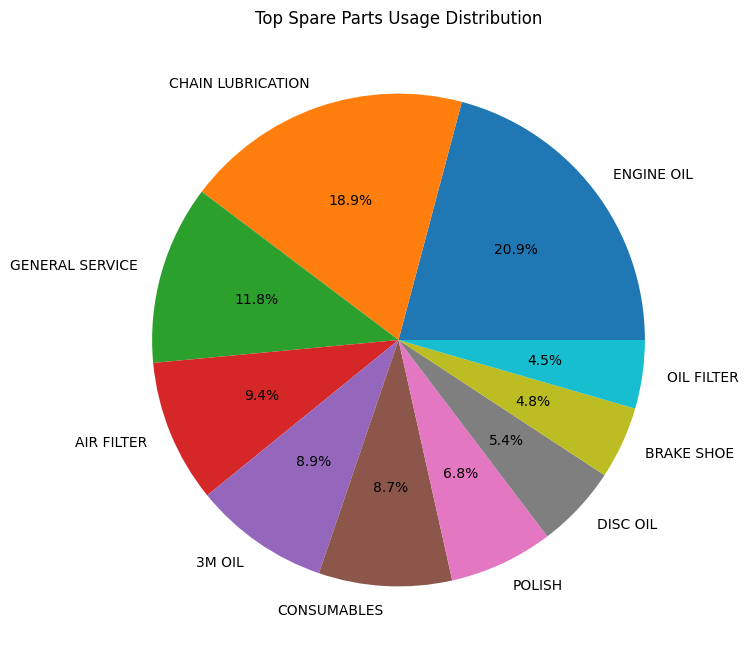

In [21]:
spare_parts=df['invoice_line_text'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(spare_parts,
        labels=spare_parts.index,
        autopct='%1.1f%%')
plt.title("Top Spare Parts Usage Distribution")
plt.show()

##### Insight

A few spare parts contribute to the majority of service demand.

# Invoice Month Distribution

Invoice Data represents the date when the service invoice was generated. By extracting the month from the invoice date, we can analyze monthly service activity. This helps identify seasonal patterns in vehicle servicing and spare parts demand.

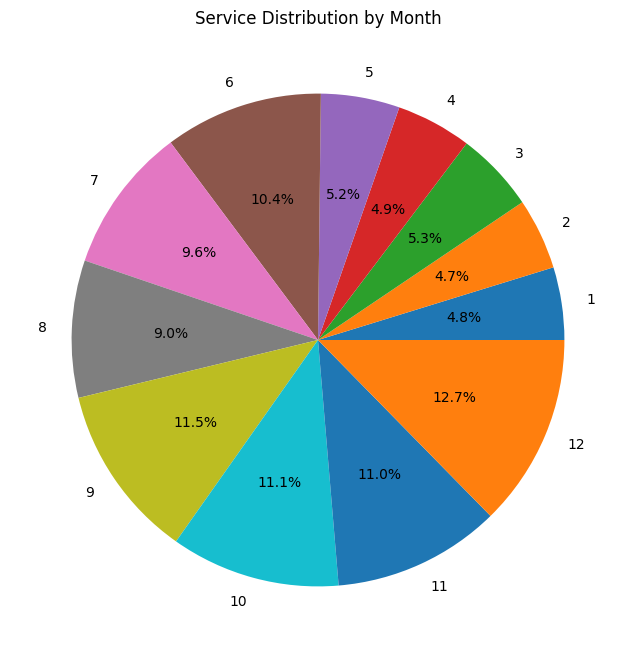

In [22]:
df['invoice_month']=df['invoice_date'].dt.month
invoice_month=df['invoice_month'].value_counts().sort_index()

plt.figure(figsize=(8,8))
plt.pie(invoice_month,
        labels=invoice_month.index,
        autopct='%1.1f%%')
plt.title("Service Distribution by Month")
plt.show()

##### Insight

Certain months show higher service activity.

# Job Card Month Distribution

The job card date indicates when the service request was initially registered. Analyzing job card dates helps understand the service workload distribution across months. Comparing job card trends with invoice dates helps evaluate service processing efficiency.

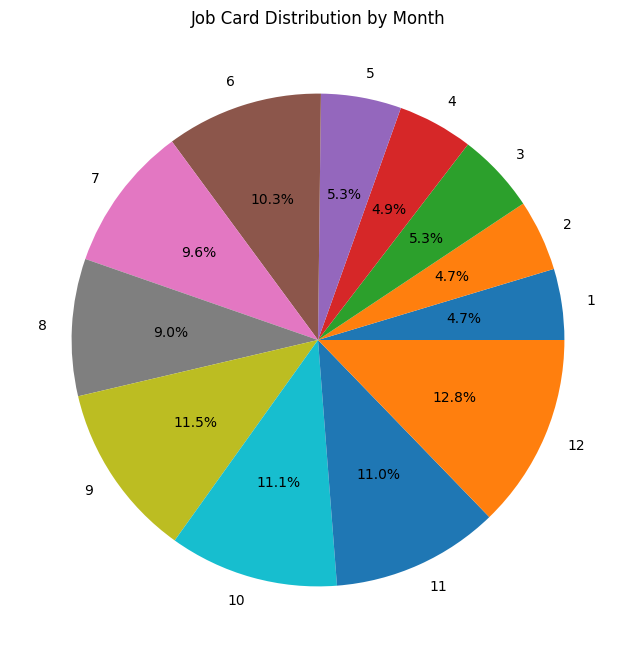

In [23]:
df['job_month']=df['job_card_date'].dt.month
job_month=df['job_month'].value_counts().sort_index()

plt.figure(figsize=(8,8))
plt.pie(job_month,
        labels=job_month.index,
        autopct='%1.1f%%')
plt.title("Job Card Distribution by Month")
plt.show()

##### Insight

Job card creation trends indicate service request patterns.

# KM Reading Category Distribution

Current KM Reading represents the mileage of vehicles at the time of servicing. Vehicles with higher mileage often require more maintenance and spare parts replacements. Categorizing KM readings helps understand vehicle wear patterns and service intervals.

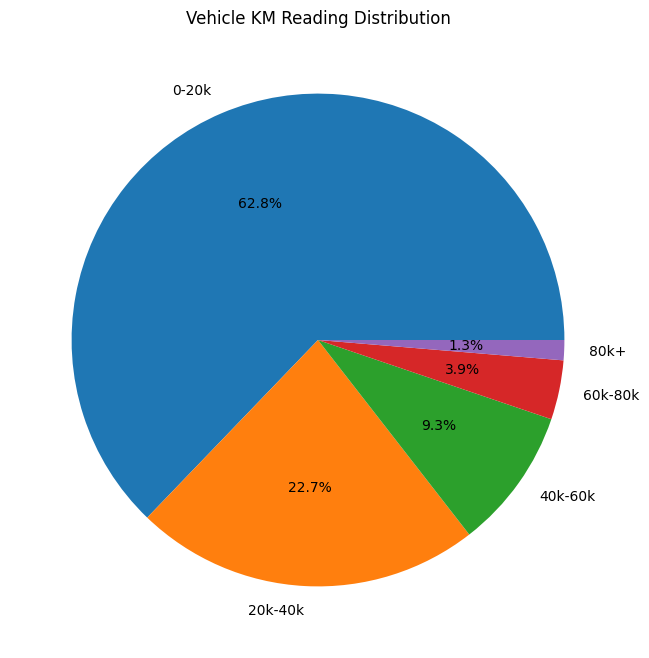

In [24]:
km_bins = pd.cut(df['current_km_reading'],
                 bins=[0,20000,40000,60000,80000,100000],
                 labels=['0-20k','20k-40k','40k-60k','60k-80k','80k+'])

km_counts = km_bins.value_counts()

plt.figure(figsize=(8,8))

plt.pie(km_counts,
        labels=km_counts.index,
        autopct='%1.1f%%')

plt.title("Vehicle KM Reading Distribution")

plt.show()

##### Insight

Vehicles with mid-range mileage appear most frequently in servicing.

# Vehicle Number Frequency

Vehicle number identifies individual vehicles visiting the service center. Some vehicles may visit the service center multiple times due to frequent maintenance or usage intensity. Analyzing vehicle frequency helps identify repeat customers and high-maintenance vehicles.

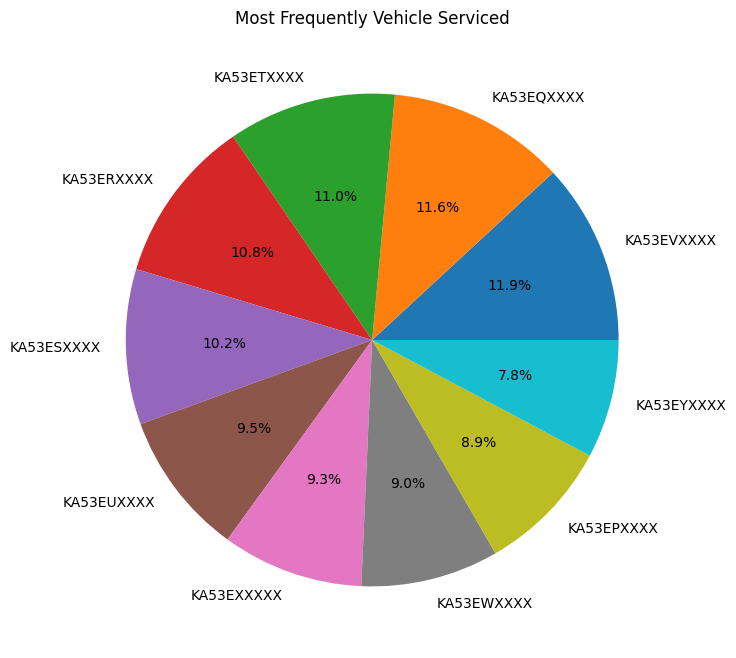

In [25]:
vehicle_counts=df['vehicle_no'].value_counts().head(10)

plt.figure(figsize=(8,8))
plt.pie(vehicle_counts,
        labels=vehicle_counts.index,
        autopct='%1.1f%%')
plt.title("Most Frequently Vehicle Serviced")
plt.show()

##### Insight

Certain vehicles visit the service center more frequently.

# Encoding Categorical Variables

Machine learning models require numerical input values. Since some columns contain text data such as vehicle models and spare parts descriptions, they must be converted into numerical form. The LabelEncoder technique assigns numerical labels to each category.

In [26]:
le=LabelEncoder()

df['vehicle_model']=le.fit_transform(df['vehicle_model'])
df['business_partner_name']=le.fit_transform(df['business_partner_name'])
df['invoice_line_text']=le.fit_transform(df['invoice_line_text'])

##### Insight

Encoding categorical variables allows machine learning algorithms to process textual data efficiently.

# Heatmap

A heatmap is an effective visualization used in Exploratory Data Analysis (EDA) to identify relationships between variables in a dataset. In this project, the dataset contains both categorical variables (Vehicle Model, Business Partner Name, INVOICE LINE TEXT, Vehicle No.) and numerical variables (Current KM Reading, Date features). Since correlation analysis only works with numerical data, categorical variables must first be converted into numerical form using encoding techniques. After encoding all columns, a correlation matrix can be generated to visualize the relationships among all variables in the dataset.

The heatmap visually represents correlation values between variables using color intensity. Values closer to +1 indicate strong positive relationships, values near -1 indicate strong negative relationships, and values around 0 indicate weak or no relationship. By analyzing correlations between features such as vehicle model, spare parts usage, service dates, and vehicle mileage, we can better understand the factors influencing spare parts demand.

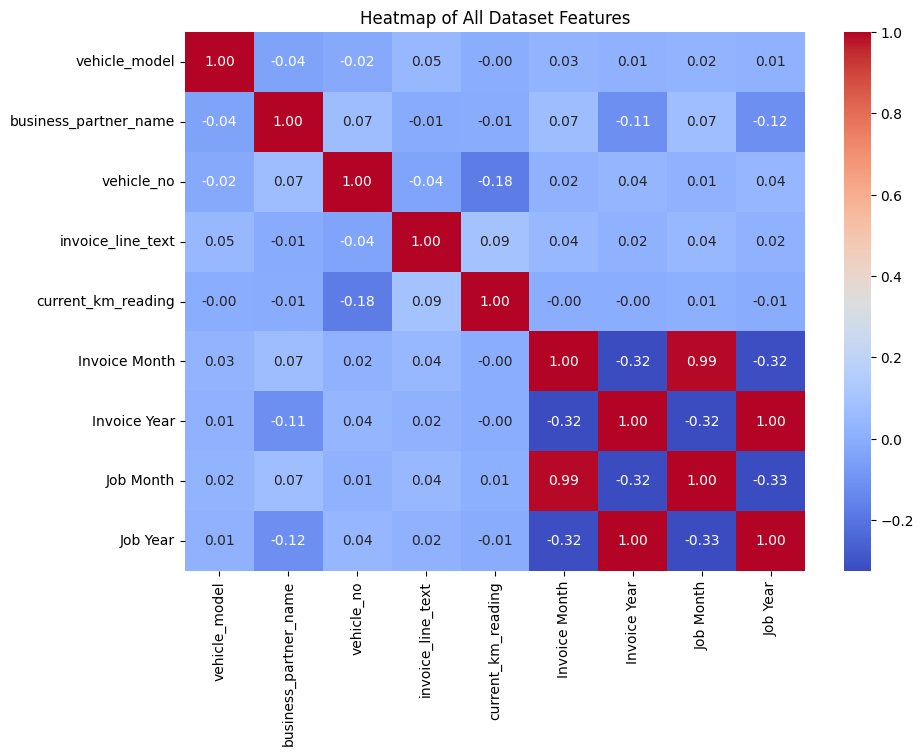

In [27]:
df['Invoice Month'] = df['invoice_date'].dt.month
df['Invoice Year'] = df['invoice_date'].dt.year
df['Job Month'] = df['job_card_date'].dt.month
df['Job Year'] = df['job_card_date'].dt.year

le = LabelEncoder()

df['vehicle_model'] = le.fit_transform(df['vehicle_model'])
df['business_partner_name'] = le.fit_transform(df['business_partner_name'])
df['invoice_line_text'] = le.fit_transform(df['invoice_line_text'])
df['vehicle_no'] = le.fit_transform(df['vehicle_no'])

all_columns = df[['vehicle_model',
                  'business_partner_name',
                  'vehicle_no',
                  'invoice_line_text',
                  'current_km_reading',
                  'Invoice Month',
                  'Invoice Year',
                  'Job Month',
                  'Job Year']]


corr_matrix = all_columns.corr()


plt.figure(figsize=(10,7))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Heatmap of All Dataset Features")

plt.show()

### Explanation of the Heatmap

The heatmap shows how each variable in the dataset is related to other variables. Each cell represents the correlation coefficient between two features. For example, the relationship between Vehicle Model and INVOICE LINE TEXT may indicate that specific vehicle models frequently require certain spare parts. Similarly, correlations between Current KM Reading and spare parts usage can help identify maintenance patterns related to vehicle mileage.

Analyzing the relationships between Invoice Month, Job Month, and Year features also helps identify temporal patterns in service demand. These patterns are essential for understanding when spare parts demand increases or decreases.

### Insights from the Heatmap

• Vehicle Model and Spare Parts may show moderate correlation, indicating that specific vehicles require particular spare components.

• Invoice Month and Job Month usually show strong positive correlation because service requests and invoice generation occur during the same servicing cycle.

• Current KM Reading may show a weak-to-moderate correlation with spare parts usage, suggesting that vehicles with higher mileage tend to require more replacements.

# Feature Selection

Feature selection involves choosing the most relevant variables for model training. In this case, vehicle model, kilometer reading, and spare part description are used as input features.

In [28]:
X=df[['vehicle_model', 'current_km_reading', 'invoice_line_text']]
y=df['current_km_reading']

##### Insight

Selecting meaningful features improves model accuracy and reduces unnecessary computational complexity.

# Train Test Split

The dataset is divided into training and testing subsets. The training dataset is used to train the machine learning model, while the testing dataset is used to evaluate its performance.

In [29]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y,test_size=0.2,random_state=42)

##### Insight

Splitting the dataset prevents overfitting and ensures that the model performs well on unseen data.

# Build Machine Learning Model

A Random Forest Regressor model is used to train the dataset. Random Forest is an ensemble learning algorithm that combines multiple decision trees to produce accurate predictions.

In [30]:
model=RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

##### Insight

Random Forest models handle complex relationships in the data and are less prone to overfitting compared to single decision tree models.

# Prediction

Once the model is trained, predictions are generated using the testing dataset.

In [31]:
y_pred=model.predict(X_test)

##### Insight

Predicted values represent the model's estimation based on learned patterns from the training data.

# Model Evaluation

Model performance is evaluated using regression metrics such as MAE, RMSE, and R2 Score.

In [32]:
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2=r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 9.613078155599064
RMSE: 499.09407541993573
R2 Score: 0.9996520059118084


##### Insight

Lower MAE and RMSE values indicate better prediction accuracy, while an R2 score closer to 1 indicates that the model explains a large portion of the variance in the data.

# Inventory Demand Forecasting (Time Series)

To analyze demand patterns over time, the invoice date is converted into a monthly time period.

In [33]:
df['MonthYear']=df['invoice_date'].dt.to_period('M')

monthly_demand=df.groupby('MonthYear').size()
monthly_demand=monthly_demand.astype(int)

##### Insight

Time series data helps identify trends and seasonal variations in spare parts demand.

# ARIMA Forecasting Model

ARIMA is used for forecasting future demand based on historical data patterns.

In [34]:
model=ARIMA(monthly_demand, order=(1,1,1))
model_fit=model.fit()

##### Insight

ARIMA models are widely used for business forecasting because they capture trends, seasonality, and past demand patterns.

# Forecast Future Demand

The trained ARIMA model predicts spare parts demand for the next six months.

In [35]:
forecast=model_fit.forecast(steps=6)

print("Next 6 Months Spare Parts Demand Forecast")
print(forecast)

Next 6 Months Spare Parts Demand Forecast
2019-02    2065.794057
2019-03     962.595782
2019-04    1668.623528
2019-05    1216.778026
2019-06    1505.951304
2019-07    1320.885426
Freq: M, Name: predicted_mean, dtype: float64


##### Insight

Forecast results help service centers plan procurement and maintain optional inventory levels.

# Monthly Spare Parts Demand Forecast Visualization

After preparing the time-series data, the monthly spare demand is visualized using a line graph. The to_timestamp() function converts the period-based monthly index into a timestamp format, which allows proper plotting in Matplotlib. The graph displays both the actual historical demand and the forecasted demand values, helping to compare past trends with predicted inventory requirememts.

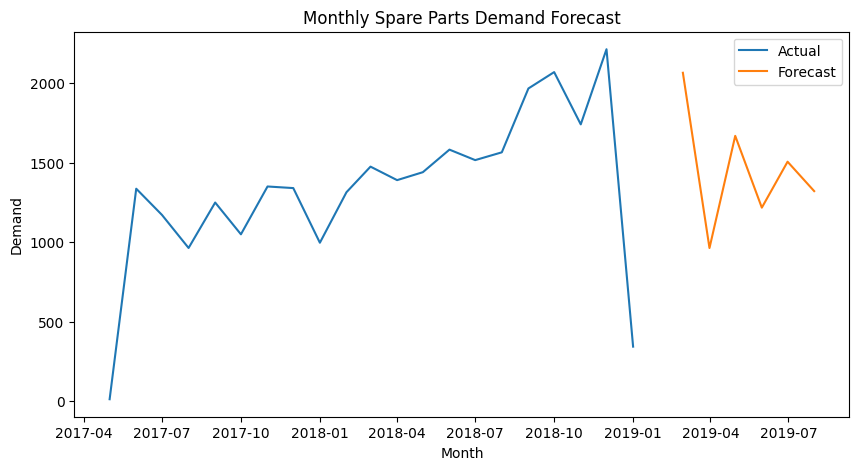

In [36]:
monthly_demand=monthly_demand.to_timestamp()

plt.figure(figsize=(10,5))

plt.plot(monthly_demand, label='Actual')
plt.plot(forecast, label='Forecast')

plt.legend()
plt.title("Monthly Spare Parts Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.show()

##### Insight

Visualizing the actual and predicted spare parts demand helps identify seasonal patterns and demand fluctuations across months. This comparison allows service centers to anticipate future inventory needs and maintain optimal stock levels, which supports Just-In-Time (JIT) inventory management and reduces holding costs.

# Future Importance Graph for Spare Parts Prediction

Feature importance helps us understand which variables influence the prediction of spare parts demand the most. In the Random Forest model, future importance measures how much each future contributes to reducing prediction error in the decision trees. By visualizing future importance, we can identify the key factors affecting inventory demand, such as time, vehicle model, spare part category.

##### Insight

Understanding future importance helps service centers focus on the most impactful variables when forecasting spare parts demand, improving the accuracy of Just-In-Time(JIT) inventory planning.

# Feature Importance Analysis for Spare Parts Demand Prediction

Future importance analysis helps identify which variables have the greatest influence on predicting spare parts demand. In a Random Forest model, each feature is assigned an importance score based on how much it contributes to reducing prediction error in the decision trees. By extracting and visualizing these scores, analysts can determine the most significant factors affecting inventory usage, which supports better decision-making and model interpretation.

              Feature  Importance
1  current_km_reading    0.998543
0       vehicle_model    0.001451
2   invoice_line_text    0.000006


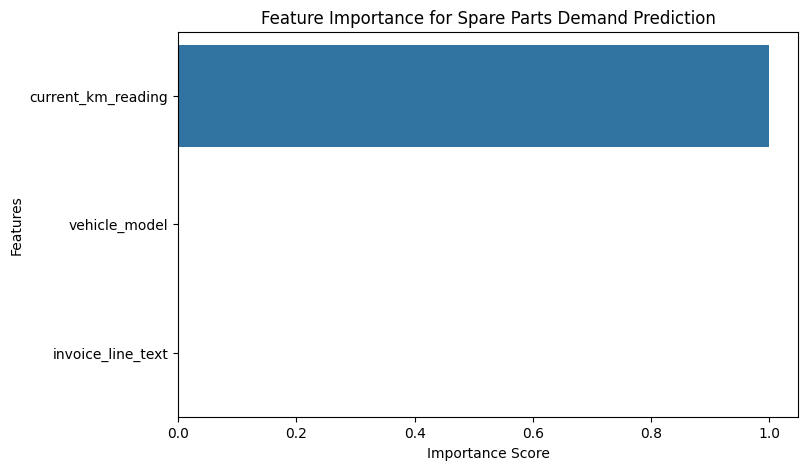

In [37]:
rf_model=RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X,y)

importance=rf_model.feature_importances_

feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
})

feature_importance=feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Feature Importance for Spare Parts Demand Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

##### Insight

The bar chart clearly shows that current_km_reading dominates the prediction process with nearly 99% importance. This indicates that the distance a vehicle has traveled is the most critical factor affecting spare parts replacement. Feature kike vehicle model invoice line text contributes very little to the prediction, suggesting that maintenance needs are primarily driven by vehicle usage rather than vehicle type or service description.

# Create Demand Data and Plot Distribution

The spare parts demand distribution graph helps visualize how frequently different spare parts are used in the service center. By analyzing the demand count of each spare part, the histogram shows the frequency distribution of concentrated among a few parts.

##### Insight

If the distribution is right-skewed, it indicates that the small number of spare parts is used very frequently, while many others are used rarely. This insight helps service centres focus on maintaining higher stock levels for high-demand parts, which supports efficient inventory management and reduces service delays.

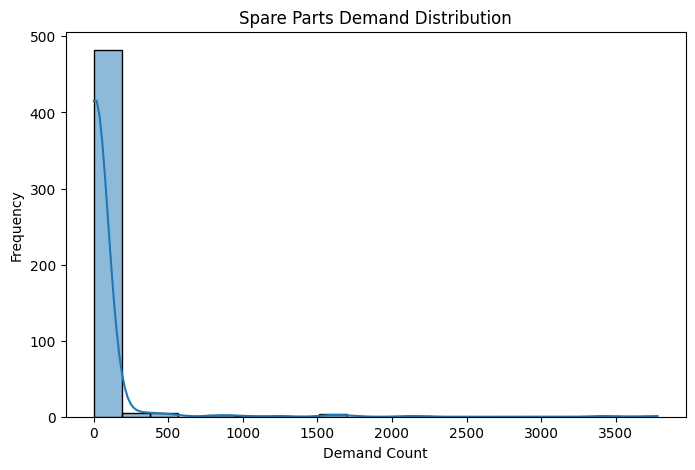

In [38]:
demand_data=df['invoice_line_text'].value_counts().reset_index()
demand_data.columns=['Spare_Part', 'Demand']

plt.figure(figsize=(8,5))

sns.histplot(demand_data['Demand'], bins=20, kde=True)

plt.title("Spare Parts Demand Distribution")
plt.xlabel("Demand Count")
plt.ylabel("Frequency")

plt.show()

#### Interpretation

The spare parts demand distribution graph shows that frequently different spare parts are used in the service centre. If the histogram displays a right-skewed distribution, it indicates that only a few spare parts are used very frequently, while most parts are used occasionally. This pattern is common in vehicle service operations, where certain components such as filters, brake pads, or engine oil parts require frequent replacement.

#### Business Insight

Understanding this demand distribution helps service centers prioritize stocking high-demand spare parts while maintaining minimal inventory for rarely used parts. This approach supports efficient inventory management, reduces storage costs, and prevents stock shortages during peak service periods, ultimately improving service efficiency ans customer satisfaction.

# Monthly Spare Parts Usage Trend Graph

The monthly spare parts usage trends graph shows how spare parts demand changes throughout different months in the service center. By grouping service records based on the month of the invoice date, this analysis helps identify patterns in vehicle servicing activities and spare parts consumption over time.

##### Insight

The line graph highlights months where spare parts usage is higher or lower. Peaks in the graph indicate months with increased vehicle servicing activity, while lower points represent periods with fewer service operations.

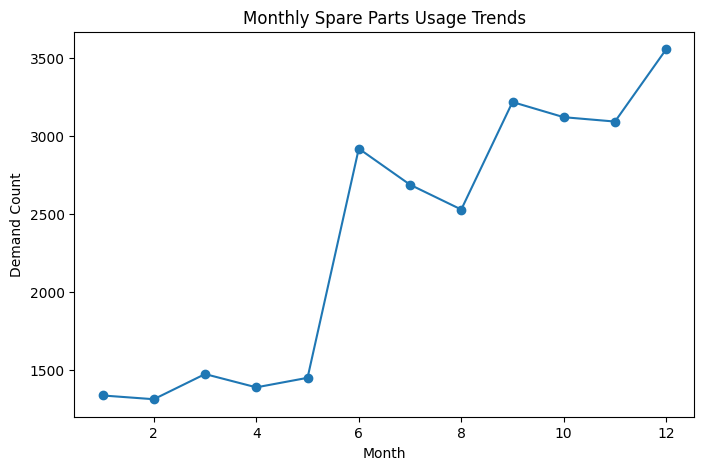

In [39]:
df['Month']=df['invoice_date'].dt.month

monthly_usage=df.groupby('Month')['invoice_line_text'].count()

plt.figure(figsize=(8,5))
monthly_usage.plot(kind='line', marker='o')
plt.title("Monthly Spare Parts Usage Trends")
plt.xlabel("Month")
plt.ylabel("Demand Count")
plt.show()

#### Interpretation

The line graph highlights months where spare parts usage is higher or lower. Peaks in the graph indicate months with increased vehicle servicing activity, while lower points represent periods with fewer service operations.

#### Business Insight

Understanding monthly demand patterns helps service centers optimize inventory planning. Proper stocking during high-demand months reduces spare parts shortages, improves service efficiency, and supports customer satisfaction.

# Top 10 Most Used Spare Parts Graph

The Top 10 Most Used Spare Parts graph identifies the spare parts that are most frequently used in vehicle servicing. By analyzing the usage count of each spare part, the visualization hightlights the components that are commonly replaced during maintenance operations.

##### Insight

High-frequency spare parts typically include components that experience regular wear and tear, such as filters, brake components, or oil-related parts.

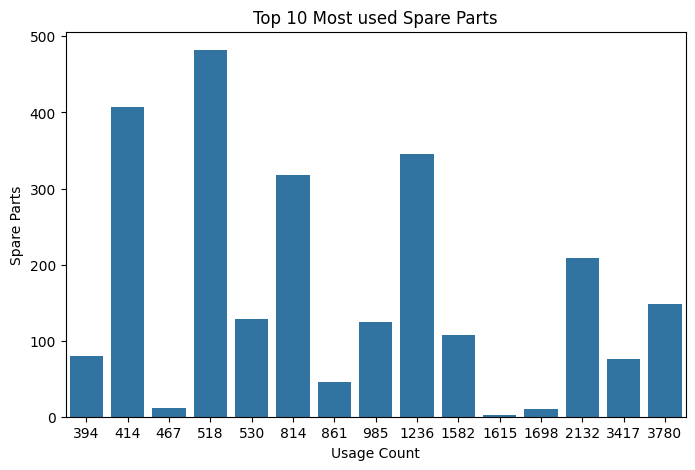

In [40]:
top_parts=df['invoice_line_text'].value_counts().head(15)

plt.figure(figsize=(8,5))
sns.barplot(x=top_parts.values, y=top_parts.index)
plt.title("Top 10 Most used Spare Parts")
plt.xlabel("Usage Count")
plt.ylabel("Spare Parts")
plt.show()

#### Interpretation

The bar chart clearly shows which spare parts have the highest usage frequency. Parts appearing at the top of the chart are those that are replaces most often in service operations.

#### Business Insight

By identifying the most frequently used spare parts, service centers can prioritize stocking these components in large quantities. This helps reduce service delays, maintain smooth operations, and improve overall inventory planning efficiency.


# Challenges Faced and Solutions in Spare Parts Inventory Forecasting

### 1. Data Quality Issues

#### Challenge

One of the major challenges in this project is data quality problems. The dataset contains missing values in important columns such as invoice data, job card date, vehicle model, current KM reading, and invoice line text. Missing or inconsistent data can negatively affect model training and lead to inaccurate predictions. Additionally, duplicate entries or incorrect formatting in the dataset can introduce noise into the analysis process.

#### Solution

To solve this problem, data cleaning and preprocessing techniques are applied. Missing values are removed using dropna() or replaced using appropriate imputation techniques. Data columns are converted into the proper datetime format for analysis. Ensuring data consistency, improving model accuracy, and helping build a reliable forecasting system.

##### Insight

Clean and well-structured data improves predictive performance and ensures reliable demand forecasting.

### 2. Understanding Spare Parts Description

#### Challenge

The column invoice line text contains a textual description of spare parts. These descriptions may have inconsistent naming conventions, spelling variations, or additional information such as quality or service notes. This makes it difficult to analyze spare parts demand directly.

#### Solution

Text preprocessing techniques are used to standardize the spare parts descriptions. Label encoding or text normalization methods are applied to convert categorical text data into a numerical format so that machine learning algorithms can process it.

##### Insight

Standardizing spare parts names improves the accuracy of demand analysis and feature importance identification.

### 3. Demand Variability

#### Challenge

Spare parts demand is not constant. It changes depending on several factors such as vehicle usage, seasonal servicing patterns, and vehicle model types. This variability makes it difficult to maintain the right inventory level.

#### Solution

EDA and time-series forecasting models like ARIMA are used to analyze demand patterns over time. By identifying seasonal trends and demand fluctuations, service centers can forecast spare parts requirements more accurately.

##### Insight

Understanding demand variability helps service centers prepare inventory in advance.

### 4. High-Dimensional Categorical Data

#### Challenge

The dataset contains multiple categorical variables, such as vehicle model, business partner name, and spare parts description. These categorical features cannot be directly used by machine learning models and must be converted into numerical form.

#### Solution

Encoding techniques such as Label Encoding or One-Hot Encoding are applied to transform categorical variables into a machine-readable format. This allows the model to understand relationships between different features.

##### Insight

Proper encoding ensures that machine learning algorithms can effectively learn patterns from categorical data.

### 5. Inventory Cost vs Avaliability Trade-off

#### Challenge

Service centers face a constant trade-off between inventory cost and spare parts availability. Maintaining excessive inventory increases storage and holding costs, while insufficient inventory can lead to service delays and customer dissatisfaction.

#### Solution

Predictive models such as Random Forest Regression and Time Series Forecasting are used to forecast spare parts demand. These models help maintain optimal stock levels and support Just-In-Time (JIT) inventory management.

##### Insight

Demand forecasting helps service centers maintain the right balance between inventory cost and spare parts availability.

### 6. Seasonal Service Demand

#### Challenge

Vehicle servicing demand may increase during specific periods such as holiday seasons or long travel periods, which leads to higher spare parts usage during those months.

#### Solution

Monthly demand analysis and time-series visualization help identify seasonal patterns in spare parts demand. Based on these insights, service centers can plan inventory procurement.

##### Insight

Seasonal forecasting ensures spare parts availability during peak service periods.

### 7. Model Selection and Accuracy

#### Challenge

Choosing the right machine learning model for forecasting spare parts demand can be challenging. Different algorithms may produce different levels of accuracy.

#### Solution

Multiple models, such as Random Forest, ARIMA, and other forecasting algorithms, are tested and evaluated using metrics such as MAE, RMSE, and r2 score. The model with the best performance is selected for the final prediction system.

##### Insight

Model evaluation ensures the forecasting system provides reliable predictions.

### 8. Large Dataset Handling

#### Challenge

The dataset contains 28,000+ service records, which requires efficient data processing and analysis.

#### Solution

Python libraries such as Pandas, Numpy, and SQLAlchemy are used for efficient data handling and database connectivity. Data is extracted directly from the MYSQL database to ensure scalable processing.

##### Insight

Efficient data handling techniques allow smooth processing of large datasets.

##### Business Impact

- Predict spare parts demands accurately.
- Reduce inventory holding costs.
- Improve spare parts availability
- Prevent stock-out situations.
- Achieve Just-In-Time(JIT) inventory management.

# Conclusion

The Spare Parts Inventory Forecasting project was developed to address one of the major operational challenges faced by vehicle service centres, which is maintaining the right balance between spare parts availability and inventory cost. Service centers often struggle with managing spare parts inventory because demand is unpredictable and depends on several factors such as vehicle model, service frequency, and vehicle usage. Maintaining excessive inventory leads to increased storage and holding costs, while insufficient inventory results in service delays and customer dissatisfaction. Therefore, implementing a predictive system for inventory forecasting is essential for improving service efficiency and operational decision-making.

In this project, service transaction data was extracted from a MYSQL database containing historical service records. The dataset includes important attributes such as invoice date, job card date, business partner name, vehicle number, vehicle model, current kilometer reading, and spare parts descriptions. These variables provide valuable information about vehicle servicing patterns and spare parts consumption. The data was first cleaned and preprocessed to handle missing values and convert date columns into meaningful time-based features such as month and year. Categorical variables were transformed into a numerical format using an encoding technique to enable machine learning analysis.

Exploratory Data Analysis (EDA) was conducted to understand the structure and behavior of the dataset. Several visualizations, such as pie charts, demand distribution graphs, monthly service trends, top spare parts analysis, and heatmaps were created to identify patterns and relationships between variables. These visualizations revealed important insights such as the dominance of certain vehicle models in service demand. Heatmap analysis further helped identify correlations between variables, allowing better feature selection for predictive modeling.

After the exploratory analysis phase, machine learning techniques were applied to develop a predictive model for spare parts inventory forecasting. A Random Forest regression model eas implemented to analyze the relationship between vehicle features and service patterns. Feature importance analysis helped identify the most influential variables affected spare parts demand, such as sapre part type, vehicle model, and vehicle mileage. In addition to machine learning models, time series forecasting techniques such as ARIMA were used to analyze historical demand trends and forecast future spare parts requirements.

The results of the predictive models demonstrated that spare parts demand follows identifiable patterns influenced by vehicle type, service intervals and usage conditions. These insights allows service centers to anticipate spare parts demand more accurately and make data-driven inventory decisions. By forecasting demand in advance, service centres can maintain optimal stock levels, reduce unnecessary inventory costs, and ensure spare parts availability during servicing operations.

One of the key outcomes of this project is the ability to support Just-In-Time (JIT) inventory management. JIT focuses on maintaining inventory only when it is required, reducing excessive storage and minimizing inventory holding costs. By using predictive analytics and demand forecasting, service centers can order sapre parts at the right time and in the right quantity. This improves operational efficiency and prevents both overstocking and stock shortages.

Overall, this project successfully demonstrates the application of the data science, machine learning, and tim eseries forecasting techniques in solving real-worlds inventory management problems. The integration od database systems, data analysis methods, predictive modeling, and visualization techniques provides a comprehensive solution for spare parts inventory forecasting. The developed system not only improves spare parts demand prediction but also supports strategic decision-making for service center management.

In conclusion, the Spare Parts Inventory Forecasting system provides a practical and scalable solution for optimizing inventory operations in vehicle service centres. By leveraging historical service data and advance analytics techniques, organizations can improve inventory planning, reduce operational costs, enhance customer satisfaction, and achieve Just-In-Time inventory management. This project highlights the importance of data-driven decision-making in modern service operations and demonstrates how predictive analytics can significantly improve inventory management practices.